In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
rabieelkharoua_cancer_prediction_dataset_path = kagglehub.dataset_download('rabieelkharoua/cancer-prediction-dataset')

print('Data source import complete.')

In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
# df=pd.read_csv("/kaggle/input/cancer-prediction-dataset/The_Cancer_data_1500_V2.csv")
df=pd.read_csv("D://N Raj//DataSet//Cancer Predicton_//The_Cancer_data_1500_V2.csv")
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


In [9]:
df.describe().sum()

Age                 1819.960968
Gender              1502.990746
BMI                 1672.634778
Smoking             1502.713095
GeneticRisk         1504.187562
PhysicalActivity    1532.439929
AlcoholIntake       1516.004828
CancerHistory       1501.495207
Diagnosis           1502.854656
dtype: float64

In [10]:
df.shape

(1500, 9)

In [11]:
df.isnull().sum()

Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

In [12]:
df.duplicated().sum()

0

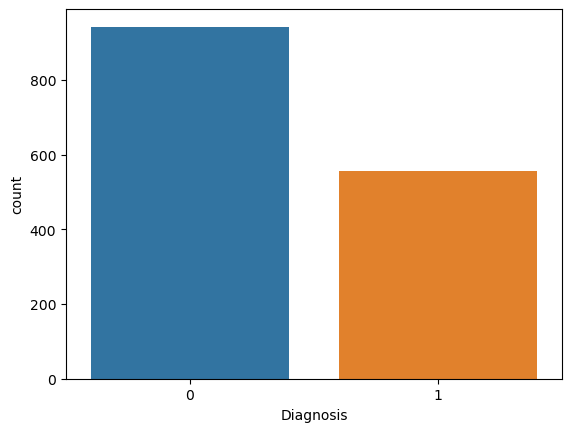

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Diagnosis", data=df)
plt.show()

<Axes: xlabel='Smoking', ylabel='count'>

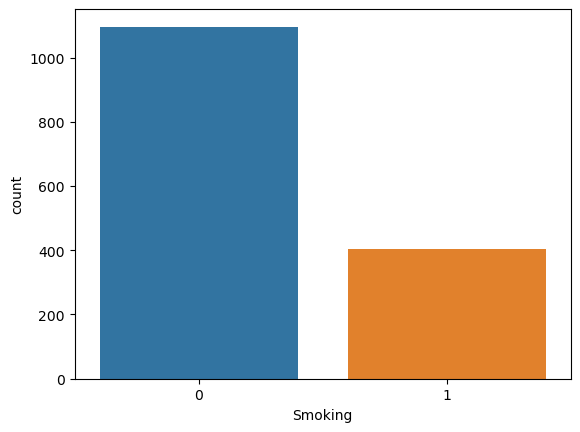

In [14]:
sns.countplot(x="Smoking",data=df)

In [15]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [16]:
import warnings
warnings.filterwarnings("ignore")

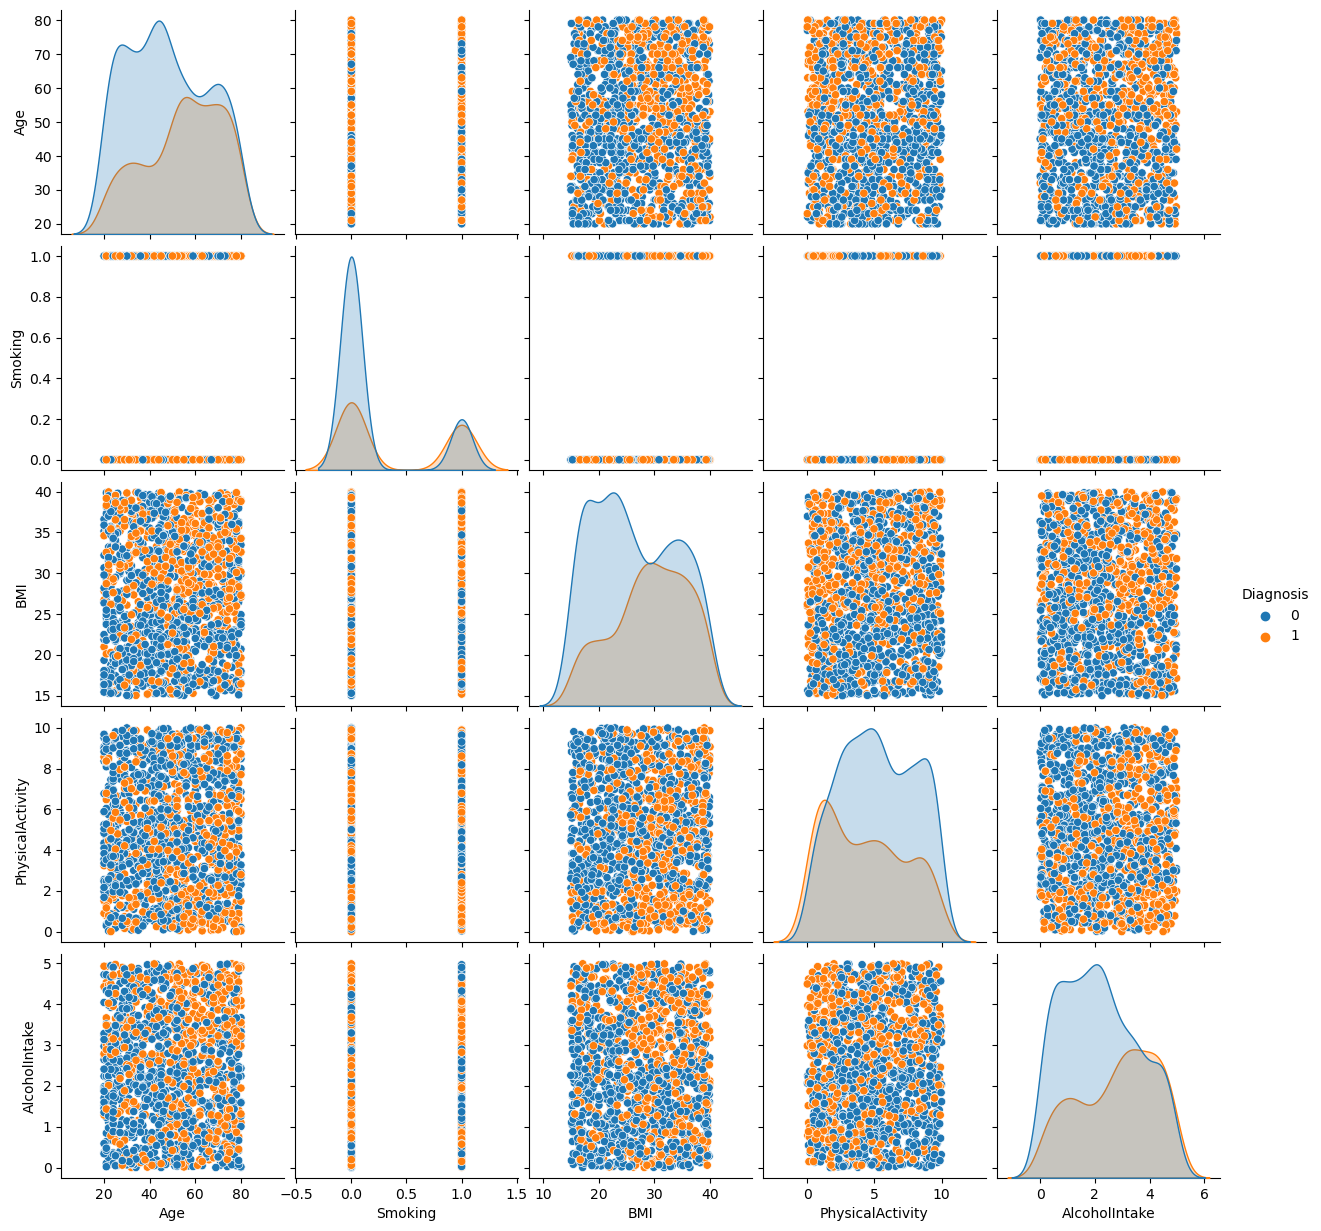

In [17]:
cols = ["Age", "Smoking", "BMI", "PhysicalActivity", "AlcoholIntake"]
sns.pairplot(df[cols + ["Diagnosis"]], hue="Diagnosis")

In [18]:
df.duplicated().sum()

0

In [19]:
df.sample(3)

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
1060,34,0,32.674412,1,0,8.814858,3.201255,0,0
944,32,0,34.044955,1,0,2.399489,2.343258,0,0
121,60,0,35.436243,0,1,1.421814,1.711670,0,0


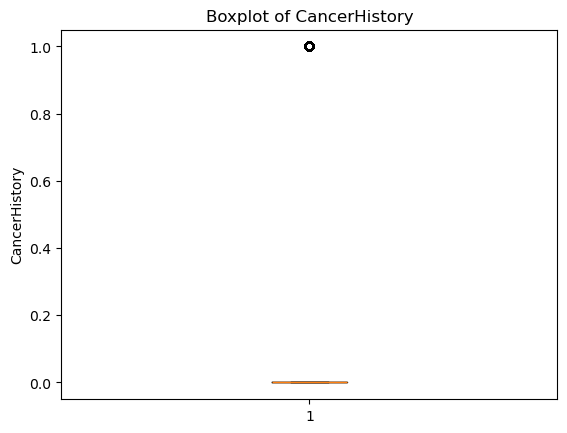

In [20]:
plt.boxplot(df["CancerHistory"])
plt.title("Boxplot of CancerHistory")
plt.ylabel("CancerHistory")
plt.show()

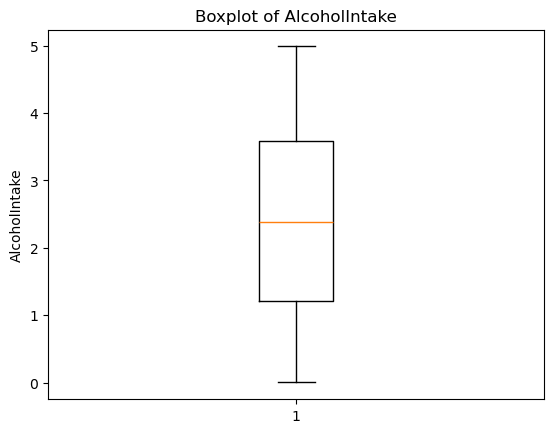

In [21]:
plt.boxplot(df["AlcoholIntake"])
plt.title("Boxplot of AlcoholIntake")
plt.ylabel("AlcoholIntake")
plt.show()

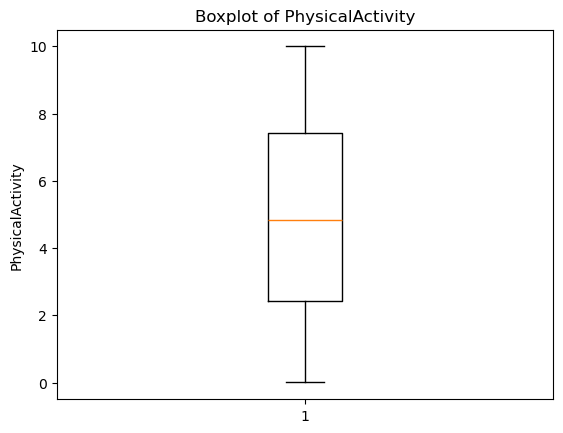

In [22]:
plt.boxplot(df["PhysicalActivity"])
plt.title("Boxplot of PhysicalActivity")
plt.ylabel("PhysicalActivity")
plt.show()

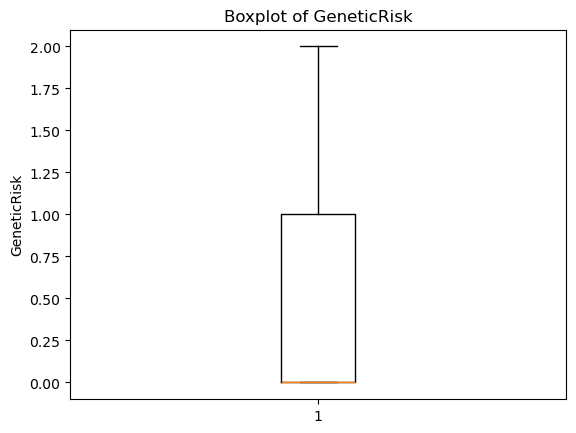

In [23]:
plt.boxplot(df["GeneticRisk"])
plt.title("Boxplot of GeneticRisk")
plt.ylabel("GeneticRisk")
plt.show()

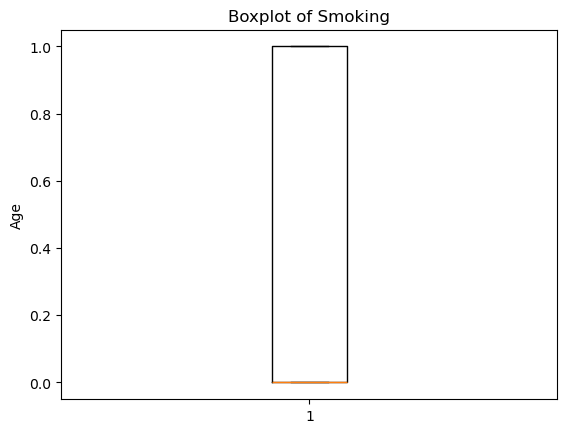

In [24]:
plt.boxplot(df["Smoking"])
plt.title("Boxplot of Smoking")
plt.ylabel("Age")
plt.show()

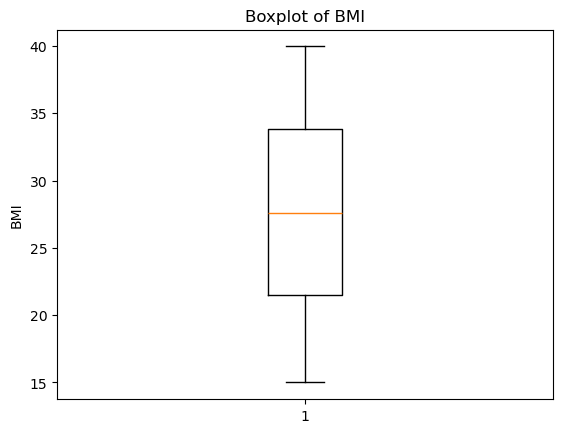

In [25]:
plt.boxplot(df["BMI"])
plt.title("Boxplot of BMI")
plt.ylabel("BMI")
plt.show()

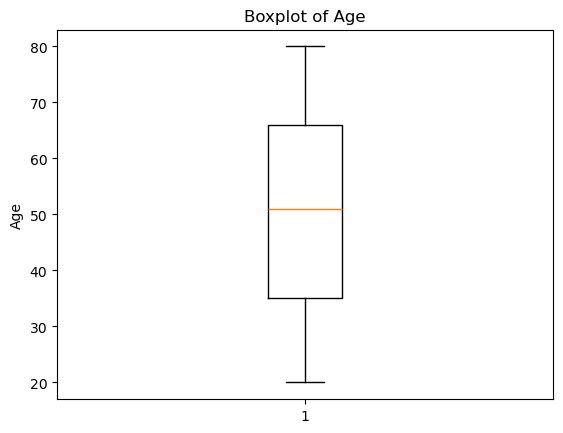

In [26]:
plt.boxplot(df["Age"])
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

<Axes: >

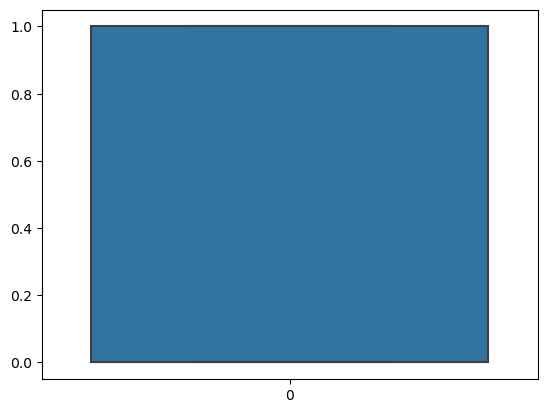

In [27]:
sns.boxplot(df["Diagnosis"])

In [28]:
df.isnull().sum()
df = df.dropna()   # or fillna() depending on data

In [29]:
df_encoded = pd.get_dummies(df, drop_first=True)

<Axes: xlabel='Diagnosis', ylabel='Age'>

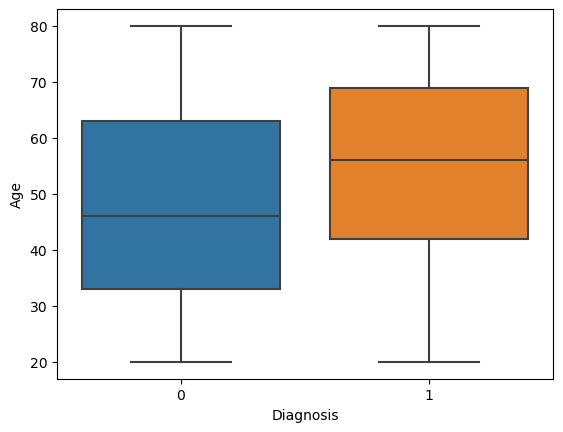

In [30]:
import seaborn as sns
sns.boxplot(x="Diagnosis", y="Age", data=df)

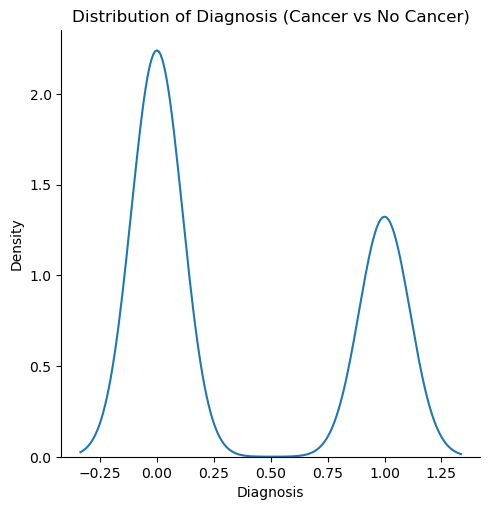

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(data=df, x="Diagnosis", kind="kde")
plt.title("Distribution of Diagnosis (Cancer vs No Cancer)")
plt.show()

In [88]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Cancer_Prediction.ipynb', 'Linear ML Implementation.ipynb', 'regmodel.pkl', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb']


In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import pickle

# Load dataset
df = pd.read_csv("heart.csv")   # Kaggle Heart Disease Dataset
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)
print("Logistic Regression:\n", classification_report(y_test, log_model.predict(X_test_scaled)))

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb.fit(X_train, y_train)
print("XGBoost:\n", classification_report(y_test, xgb.predict(X_test)))

# Save best model (suppose Random Forest best)
pickle.dump(rf, open("heart_model.pkl", "wb"))

ModuleNotFoundError: No module named 'xgboost'

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Random Forest Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

# 1. Accuracy, Precision, Recall, F1
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# 2. Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=["No Cancer","Cancer"], yticklabels=["No Cancer","Cancer"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'rf' is not defined

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Store model results in a list
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

# Plot comparison
results_df.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()

NameError: name 'log_model' is not defined

In [36]:
# Assume Random Forest is best
best_model = rf

NameError: name 'rf' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Get probability predictions (for class = 1, Cancer)
y_prob = best_model.predict_proba(X_test)[:,1]

# Calculate metrics (using actual labels vs predicted probabilities)
mse = mean_squared_error(y_test, y_prob)
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_prob)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 0.072337
MAE: 0.18723333333333333
RMSE: 0.2689553866350328
R² Score: 0.6949807908545726


In [ ]:
print(X.columns)

Index(['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity',
       'AlcoholIntake', 'CancerHistory'],
      dtype='object')


In [ ]:
import numpy as np

# Example patient data (fill values in the same order as X.columns)
new_patient = np.array([[55, 1, 28.5, 0, 1, 0, 2, 0]])

# Shape fix (model expects 2D)
prediction = best_model.predict(new_patient)
probability = best_model.predict_proba(new_patient)[:,1]

print("Prediction:", "Cancer" if prediction[0]==1 else "No Cancer")
print("Probability of Cancer:", probability[0])

Prediction: Cancer
Probability of Cancer: 0.76


In [ ]:
import joblib

# Save the best model
joblib.dump(best_model, "cancer_prediction_model.pkl")

print("OK Model saved as cancer_prediction_model.pkl")

OK Model saved as cancer_prediction_model.pkl


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 76.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.2 MB/s eta 0:00:00:00:0100:01


In [ ]:
# Load model
loaded_model = joblib.load("cancer_prediction_model.pkl")

# Example new patient input (values must follow X.columns order!)
new_patient = np.array([[55, 1, 28.5, 0, 1, 0, 2, 0]])

# Prediction
prediction = loaded_model.predict(new_patient)
probability = loaded_model.predict_proba(new_patient)[:,1]

print("Prediction:", "Cancer" if prediction[0]==1 else "No Cancer")
print("Probability of Cancer:", probability[0])

Prediction: Cancer
Probability of Cancer: 0.76


In [ ]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
pickle.dump(log_model, open("log_model.pkl", "wb"))

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
pickle.dump(rf_model, open("rf_model.pkl", "wb"))

# XGBoost
xgb_model = XGBClassifier(eval_metric="logloss")
xgb_model.fit(X_train, y_train)
pickle.dump(xgb_model, open("xgb_model.pkl", "wb"))

print("✅ All models trained and saved successfully!")

✅ All models trained and saved successfully!


In [ ]:
import streamlit as st
import numpy as np
import pickle

# -------------------------------
# Load Models
# -------------------------------
log_model = pickle.load(open("log_model.pkl", "rb"))
rf_model = pickle.load(open("rf_model.pkl", "rb"))
xgb_model = pickle.load(open("xgb_model.pkl", "rb"))

# Model dictionary for easy selection
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# -------------------------------
# App Title
# -------------------------------
st.title("🩺 Cancer Prediction Web App")
st.write("Enter patient details below to check the probability of Cancer.")

# -------------------------------
# User Input Fields
# (Make sure these features are same order as X_train.columns)
# -------------------------------
age = st.number_input("Age", 18, 100)
smoking = st.selectbox("Smoking (Yes=1, No=0)", [0, 1])
bmi = st.number_input("BMI", 10.0, 50.0)
physical = st.number_input("Physical Activity Level (0-10)", 0, 10)
alcohol = st.selectbox("Alcohol Intake (Yes=1, No=0)", [0, 1])
obesity = st.selectbox("Obesity (Yes=1, No=0)", [0, 1])
genetic_risk = st.selectbox("Genetic Risk (0=Low, 1=Medium, 2=High)", [0, 1, 2])
chronic = st.selectbox("Chronic Disease (Yes=1, No=0)", [0, 1])

# -------------------------------
# Model Selection
# -------------------------------
model_choice = st.selectbox("Select Model", ["Logistic Regression", "Random Forest", "XGBoost"])
chosen_model = models[model_choice]

# -------------------------------
# Prediction
# -------------------------------
if st.button("🔍 Predict"):
    # Arrange patient data in correct order
    patient_data = np.array([[age, smoking, bmi, physical, alcohol, obesity, genetic_risk, chronic]])

    # Prediction
    pred = chosen_model.predict(patient_data)
    prob = chosen_model.predict_proba(patient_data)[:, 1]

    st.subheader(f"Prediction Result using {model_choice}:")
    st.write("🟢 No Cancer" if pred[0] == 0 else "🔴 Cancer Detected")
    st.write(f"Probability of Cancer: {prob[0]*100:.2f}%")

2025-09-12 16:08:17.033 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-12 16:08:17.155 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-09-12 16:08:17.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-12 16:08:17.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-12 16:08:17.158 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-12 16:08:17.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-12 16:08:17.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-12 16:08:17.161 Thread 'MainThread': mi

In [ ]:
streamlit run app.py